In [1]:
import os, glob, re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import AutoMinorLocator
from IPython.display import display, FileLink

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"],
    "text.latex.preamble": r"""
        \usepackage[T1]{fontenc}
        \usepackage[utf8]{inputenc}
        \usepackage{xcolor}
        \usepackage{amsmath}
        \usepackage{amssymb}
        \usepackage{helvet}
        \renewcommand{\familydefault}{\sfdefault}
        \usepackage{sansmath}
        \sansmath
    """,
})


def hex2rgb(h):
    h = h.lstrip('#')
    return tuple(int(h[i:i+2], 16)/255.0 for i in (0, 2, 4))

line_colors_hex = ['#1f77b4', '#d78e20', '#c459a1', '#498c41']
line_colors = [hex2rgb(h) for h in line_colors_hex]



font_scale = 1.5
label_fs = int(12 * font_scale)
legend_fs = int(9 * font_scale)
tick_labelsize = int(10 * font_scale)
scaled_markersize = int(4 * font_scale)

PT_PER_INCH = 72
FIGSIZE = (500 / PT_PER_INCH, 320 / PT_PER_INCH)

In [2]:
def extract_k_from_name(name):
    m = re.search(r"_k(\d+)", name)
    return int(m.group(1)) if m else None

def extract_n_from_name(name):
    m = re.search(r"_n(\d+)", name)
    return int(m.group(1)) if m else None

def extract_trials_from_name(name):
    m = re.search(r"_trials(\d+)", name)
    return int(m.group(1)) if m else None

def extract_steps_from_name(name):
    m = re.search(r"_steps(?:_max)?([0-9p]+)", name)
    if not m:
        return None
    s = m.group(1).replace('p', '.')
    try:
        return float(s)
    except Exception:
        return None    
def extract_shots_from_name(name):
    m = re.search(r"_shots(\d+)", name)
    return int(m.group(1)) if m else None

def find_repo_root(start=None):
    p = os.path.abspath(start or os.getcwd())
    while True:
        if (os.path.exists(os.path.join(p, 'cyclic_project'))
            or os.path.exists(os.path.join(p, '.git'))
            or os.path.exists(os.path.join(p, 'README.md'))):
            return p
        parent = os.path.dirname(p)
        if parent == p:
            return None
        p = parent

In [3]:
# --- build list of CSV files that contain steps + fidelity ---

repo_root = find_repo_root()
if repo_root is None:
    raise RuntimeError("Could not find repo root")

print(f"[+] Repo root: {repo_root}")

candidate_files = sorted(
    glob.glob(
        os.path.join(repo_root, "**", "*.csv"),
        recursive=True,
    )
)
print(f"[+] Found {len(candidate_files)} total CSVs")

files = []
for f in candidate_files:
    try:
        df0 = pd.read_csv(f, nrows=1)
    except Exception:
        continue

    cols = [c.strip().lower() for c in df0.columns]

    if "steps" in cols and "fidelity" in cols:
        files.append(f)

print(f"[+] Using {len(files)} CSVs with columns steps,fidelity")

[+] Repo root: /Users/vanladmon/Github/OQPA
[+] Found 5511 total CSVs
[+] Using 10 CSVs with columns steps,fidelity


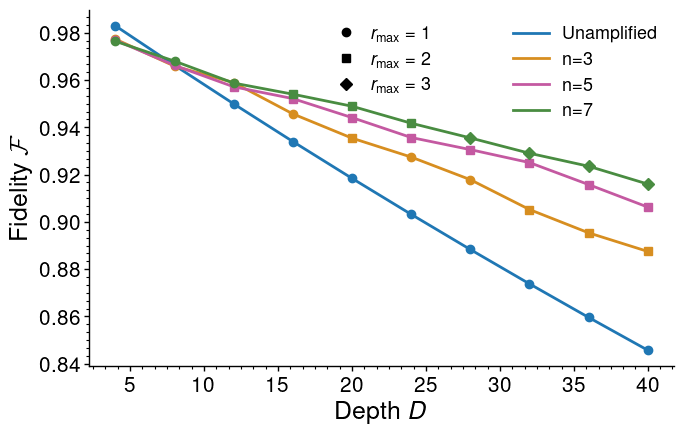

[+] Saved to fidelity_vs_depth_maxR_overlay_with_Rmarkers_0p001.svg


In [4]:
from matplotlib.ticker import AutoMinorLocator

PT_PER_INCH = 72
FIGSIZE = (500 / PT_PER_INCH, 320 / PT_PER_INCH)


def plot_max_over_R_with_R_markers(files, out_path=None):
    rows = []

    for f in files:
        try:
            df = pd.read_csv(f)
        except Exception:
            continue

        # Expect steps-sweep CSVs
        if "steps" not in df.columns or "fidelity" not in df.columns:
            continue

        basename = os.path.basename(f)
        n = extract_n_from_name(basename)
        R = extract_trials_from_name(basename)

        if n is None or R is None:
            continue

        for _, row in df.iterrows():
            step_val = float(row["steps"])
            rows.append(
                {
                    "n": int(n),
                    "R": int(R),
                    "steps": step_val,
                    "depth": 2.0 * step_val,
                    "fidelity": float(row["fidelity"]),
                }
            )

    if not rows:
        print("No data found")
        return

    all_df = pd.DataFrame(rows)

    # For each (n, steps), choose row with max fidelity; tie break by smaller R
    all_df = all_df.sort_values(
        ["n", "steps", "fidelity", "R"],
        ascending=[True, True, False, True],
    )
    best = all_df.groupby(["n", "steps"], as_index=False).first()

    # Map each unique R to a marker
    unique_R = sorted(best["R"].unique())
    marker_cycle = [
        "o", "s", "D", "^", "v", "<", ">", "P", "X",
        "*", "h", "H", "p", "d"
    ]
    r_to_marker = {
        r: marker_cycle[i % len(marker_cycle)]
        for i, r in enumerate(unique_R)
    }

    fig, ax = plt.subplots(figsize=FIGSIZE)

    for idx, nval in enumerate(sorted(best["n"].unique())):
        sub = best[best["n"] == nval].sort_values("steps")

        label = "Unamplified" if int(nval) == 1 else f"n={int(nval)}"
        color = (
            line_colors[idx % len(line_colors)]
            if "line_colors" in globals()
            else None
        )

        # Draw line vs depth = 2 * steps
        ax.plot(
            sub["depth"],
            sub["fidelity"],
            linestyle="-",
            linewidth=2,
            color=color,
            label=label,
        )

        # Overlay markers by selected R
        for r in unique_R:
            sub_r = sub[sub["R"] == r]
            if len(sub_r) == 0:
                continue

            ax.plot(
                sub_r["depth"],
                sub_r["fidelity"],
                linestyle="None",
                marker=r_to_marker[r],
                markersize=scaled_markersize,
                color=color,
            )

    ax.set_xlabel(r"Depth $D$", fontsize=label_fs)
    ax.set_ylabel(r"Fidelity $\mathcal{F}$", fontsize=label_fs)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1)
    ax.spines["bottom"].set_linewidth(1)

    ax.xaxis.set_ticks_position("bottom")
    ax.yaxis.set_ticks_position("left")

    ax.xaxis.set_minor_locator(AutoMinorLocator(6))
    ax.yaxis.set_minor_locator(AutoMinorLocator(6))

    ax.tick_params(which="major", direction="out", width=1,labelsize=tick_labelsize)
    ax.tick_params(which="minor", direction="out", width=0.8)

    # Legend for n (colors)
    leg1 = ax.legend(
        loc="upper right",
        fontsize=legend_fs,
        frameon=False,
    )
    ax.add_artist(leg1)

    # Legend for R (markers)
    marker_handles = [
        plt.Line2D(
            [0],
            [0],
            marker=r_to_marker[r],
            linestyle="None",
            color="black",
            markersize=scaled_markersize,
            label=rf"$r_\mathrm{{max}}={r}$",
        )
        for r in unique_R
    ]

    ax.legend(
        handles=marker_handles,
        loc="upper left",
        bbox_to_anchor=(0.38, 1.0),
        columnspacing=0.8,
        handletextpad=0.4,
        fontsize=legend_fs,
        frameon=False,
    )

    if out_path is None:
        out_path = "fidelity_vs_depth_maxR_overlay_with_Rmarkers_0p001.svg"

    fig.tight_layout()
    fig.savefig(out_path)
    plt.show()
    plt.close(fig)

    print(f"[+] Saved to {out_path}")


plot_max_over_R_with_R_markers(files)

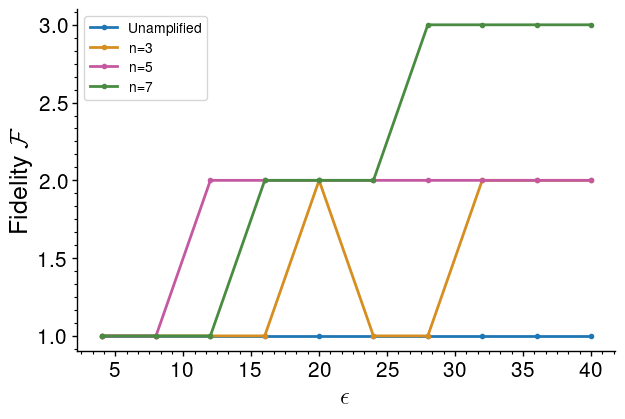

[+] Saved to None


In [5]:
from matplotlib.ticker import AutoMinorLocator

PT_PER_INCH = 72
FIGSIZE = (500 / PT_PER_INCH, 320 / PT_PER_INCH)

def plot_best_R_over_steps(files, out_path=None):
    rows = []
    for f in files:
        try:
            df = pd.read_csv(f)
        except Exception:
            continue
        if "steps" not in df.columns or "fidelity" not in df.columns:
            continue

        basename = os.path.basename(f)
        n = extract_n_from_name(basename)
        R = extract_trials_from_name(basename)

        if n is None or R is None:
            continue

        for _, row in df.iterrows():
            rows.append({
                "n": int(n),
                "R": int(R),
                "steps": int(row["steps"]),
                "fidelity": float(row["fidelity"]),
            })

    if not rows:
        print("No data found")
        return

    all_df = pd.DataFrame(rows)

    # For each (n, steps), pick the row with max fidelity; break ties by smaller R
    all_df = all_df.sort_values(["n", "steps", "fidelity", "R"], ascending=[True, True, False, True])
    best = all_df.groupby(["n", "steps"], as_index=False).first()

    fig, ax = plt.subplots(figsize=FIGSIZE)

    for idx, nval in enumerate(sorted(best["n"].unique())):
        sub = best[best["n"] == nval].sort_values("steps")
        label = "Unamplified" if int(nval) == 1 else f"n={int(nval)}"
        color = line_colors[idx % len(line_colors)] if "line_colors" in globals() else None

        ax.plot(
            sub["steps"] * 2,
            sub["R"],
            marker=".",
            linewidth=2,
            label=label,
            color=color
        )

    ax.set_xlabel(r"$\epsilon$", fontsize=label_fs)
    ax.set_ylabel(r"Fidelity $\mathcal{F}$", fontsize=label_fs)

    # Only left and bottom spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1)
    ax.spines["bottom"].set_linewidth(1)
    ax.xaxis.set_ticks_position("bottom")
    ax.yaxis.set_ticks_position("left")

    # 5 minor ticks between major ticks
    ax.xaxis.set_minor_locator(AutoMinorLocator(6))
    ax.yaxis.set_minor_locator(AutoMinorLocator(6))
    ax.tick_params(which="major", direction="out", width=1, labelsize=tick_labelsize)
    ax.tick_params(which="minor", direction="out", width=0.8)

    ax.legend()

    plt.show(fig)
    
    plt.close(fig)
    print(f"[+] Saved to {out_path}")
plot_best_R_over_steps(files)

[+] Saved to fidelity_vs_steps_all_R_shaded.svg


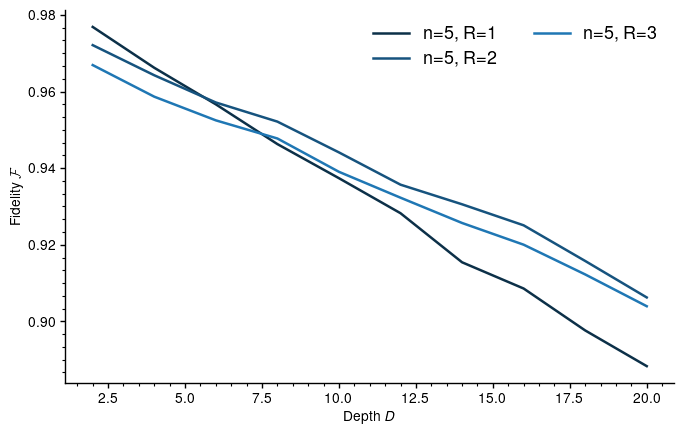

In [6]:
def plot_all_R_shaded(files, out_path=None):
    rows = []

    for f in files:
        try:
            df = pd.read_csv(f)
        except Exception:
            continue

        if "steps" not in df.columns or "fidelity" not in df.columns:
            continue

        basename = os.path.basename(f)
        n = extract_n_from_name(basename)
        R = extract_trials_from_name(basename)

        if n is None or R is None:
            continue

        for _, row in df.iterrows():
            rows.append(
                {
                    "n": int(n),
                    "R": int(R),
                    "steps": float(row["steps"]),
                    "fidelity": float(row["fidelity"]),
                }
            )

    if not rows:
        print("No data found")
        return

    df_all = pd.DataFrame(rows)

    fig, ax = plt.subplots(figsize=FIGSIZE)

    unique_n = sorted(df_all["n"].unique())
    for idx_n, nval in enumerate([5]):
        sub_n = df_all[df_all["n"] == nval]
        base_color = line_colors[idx_n % len(line_colors)]

        unique_R = sorted(sub_n["R"].unique())

        for idx_r, rval in enumerate(unique_R):
            sub_r = sub_n[sub_n["R"] == rval].sort_values("steps")

            # create lighter shade for increasing R
            shade_factor = 0.4 + 0.6 * (idx_r / max(1, len(unique_R) - 1))
            shaded_color = tuple(shade_factor * c for c in base_color)

            label = f"n={nval}, R={rval}"

            ax.plot(
                sub_r["steps"],
                sub_r["fidelity"],
                linewidth=1.8,
                color=shaded_color,
                label=label,
            )

    ax.set_xlabel(r"Depth $D$")
    ax.set_ylabel(r"Fidelity $\mathcal{F}$")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1)
    ax.spines["bottom"].set_linewidth(1)

    ax.xaxis.set_ticks_position("bottom")
    ax.yaxis.set_ticks_position("left")

    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(6))

    ax.tick_params(which="major", direction="out", width=1)
    ax.tick_params(which="minor", direction="out", width=0.8)

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontfamily("Helvetica")

    ax.legend(fontsize=legend_fs, frameon=False, ncol=2)

    if out_path is None:
        out_path = "fidelity_vs_steps_all_R_shaded.svg"

    fig.tight_layout()
    fig.savefig(out_path)
    print(f"[+] Saved to {out_path}")
    plt.show()
    plt.close(fig)


plot_all_R_shaded(files)